### K Nearest Neighbors (KNN) Classifier

In [18]:
import pandas as pd
import numpy as np

In [4]:
# Get data as a pandas DataFrame
churn_df = pd.read_csv("data/telecom_churn.csv")

# Inspect the DataFrame
churn_df.head()

,Unnamed: 0,account_length,area_code,international_plan,voice_mail_plan,number_vmail_messages,total_day_minutes,total_day_calls,total_day_charge,total_eve_minutes,total_eve_calls,total_eve_charge,total_night_minutes,total_night_calls,total_night_charge,total_intl_minutes,total_intl_calls,total_intl_charge,customer_service_calls,churn
0,0,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,1,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,2,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,3,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,4,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


In [12]:
from sklearn.neighbors import KNeighborsClassifier

y = churn_df["churn"].values
X = churn_df[["account_length", "customer_service_calls"]].values

knn = KNeighborsClassifier(n_neighbors=6)

knn.fit(X, y)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",6
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [ ]:
# Create X_new, a 2D NumPy array with three new observations
X_new = np.array([[30.0, 17.5],
                [107.0, 24.1],
                [213.0, 10.9]])

In [20]:
# predict the labels for the new observations
predictions = knn.predict(X_new)
print(predictions)

[0 1 0]


### Model Performance

In [21]:
from sklearn.model_selection import train_test_split

X = churn_df.drop("churn", axis=1).values
y = churn_df["churn"].values

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1, stratify=y)
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Evaluate the model on the test set
test_accuracy = knn.score(X_test, y_test)
print("Test set accuracy: {:.2f}".format(test_accuracy))

Test set accuracy: 0.85


### Overfitting and Underfitting

In [23]:
# Neighbor values
neighbors = np.arange(1, 20)
train_accuracies = {}
test_accuracies = {}

for neighbor in neighbors:
    knn = KNeighborsClassifier(n_neighbors=neighbor)
    knn.fit(X_train, y_train)
    
    train_accuracies[neighbor] = knn.score(X_train, y_train)
    test_accuracies[neighbor] = knn.score(X_test, y_test)
    
# Print the training and testing accuracies for each neighbor value
for neighbor in neighbors:
    print("Neighbor: {}, Training Accuracy: {:.2f}, Testing Accuracy: {:.2f}".format(
        neighbor, train_accuracies[neighbor], test_accuracies[neighbor]))

Neighbor: 1, Training Accuracy: 1.00, Testing Accuracy: 0.82
Neighbor: 2, Training Accuracy: 0.89, Testing Accuracy: 0.86
Neighbor: 3, Training Accuracy: 0.90, Testing Accuracy: 0.85
Neighbor: 4, Training Accuracy: 0.87, Testing Accuracy: 0.85
Neighbor: 5, Training Accuracy: 0.88, Testing Accuracy: 0.85
Neighbor: 6, Training Accuracy: 0.87, Testing Accuracy: 0.86
Neighbor: 7, Training Accuracy: 0.88, Testing Accuracy: 0.86
Neighbor: 8, Training Accuracy: 0.86, Testing Accuracy: 0.86
Neighbor: 9, Training Accuracy: 0.87, Testing Accuracy: 0.86
Neighbor: 10, Training Accuracy: 0.86, Testing Accuracy: 0.85
Neighbor: 11, Training Accuracy: 0.86, Testing Accuracy: 0.85
Neighbor: 12, Training Accuracy: 0.86, Testing Accuracy: 0.85
Neighbor: 13, Training Accuracy: 0.86, Testing Accuracy: 0.86
Neighbor: 14, Training Accuracy: 0.86, Testing Accuracy: 0.86
Neighbor: 15, Training Accuracy: 0.86, Testing Accuracy: 0.86
Neighbor: 16, Training Accuracy: 0.86, Testing Accuracy: 0.86
Neighbor: 17, Tra

### Visualize Model Complexity

In [24]:
import matplotlib.pyplot as plt

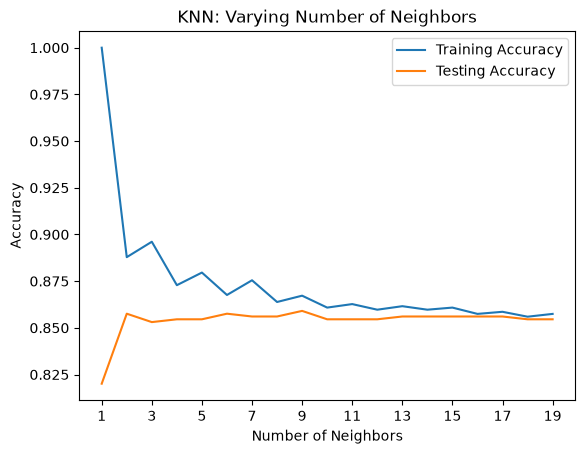

In [26]:
# Add title
plt.title("KNN: Varying Number of Neighbors")

plt.plot(neighbors, train_accuracies.values(), label="Training Accuracy")
plt.plot(neighbors, test_accuracies.values(), label="Testing Accuracy")

plt.legend()
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")

plt.xticks(np.arange(1, 20, 2))
plt.show()

### Intro to Regression

In [27]:
import numpy as np

In [28]:
# Get data from a CSV file as a pandas DataFrame
sales_df = pd.read_csv("data/sales.csv")

# Inspect the DataFrame
sales_df.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


In [33]:
X = sales_df["radio"].values
y = sales_df["sales"].values

print(X.shape, y.shape)

# We need to reshape X to be a 2D array with one column since we need to pass a 2D array as a feature matrix
X = X.reshape(-1, 1)
print(X.shape, y.shape)

(4546,) (4546,)
(4546, 1) (4546,)


#### Linear Regression

In [34]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression()

reg.fit(X, y)

predictions = reg.predict(X)
print(predictions)

[ 95491.17119147 117829.51038393 173423.38071499 ... 206147.61403088
 187204.93183873 174094.31771993]


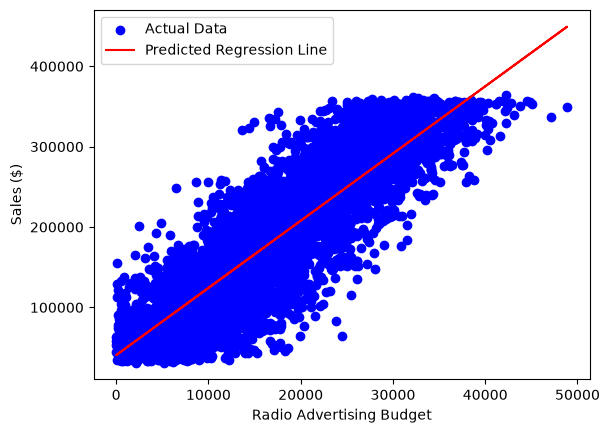

In [38]:
# Visualize linear regression predictions
import matplotlib.pyplot as plt

plt.scatter(X, y, color='blue', label='Actual Data')

plt.plot(X, predictions, color='red', label='Predicted Regression Line')
plt.xlabel('Radio Advertising Budget')
plt.ylabel('Sales ($)')

plt.legend()
plt.show()

In [ ]:
# Create the whole feature matrix X and target vector y
X = sales_df.drop(["sales", "influencer"], axis=1).values # drop influencer column since it is not a numeric feature
y = sales_df["sales"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

reg = LinearRegression()

reg.fit(X_train, y_train)   

y_pred = reg.predict(X_test)
print("Predictions: {}, Actual Values: {}".format(y_pred[:2], y_test[:2]))

Predictions: [331134.05780539  96097.48620491], Actual Values: [329147.81 100145.86]


### Regression Performance

In [45]:
# RMSE is a common metric used to evaluate the performance of regression models. 
# It is calculated as the square root of the mean squared error (MSE) between the predicted and actual values. 

from sklearn.metrics import root_mean_squared_error

# R Squared is a statistical measure that represents the proportion of the variance 
# for a dependent variable that's explained by an independent variable or variables 
r_squared = reg.score(X_test, y_test)

rmse = root_mean_squared_error(y_test, y_pred)

# Print the metrics
print("R Squared: {}".format(r_squared))
print("Root Mean Squared Error: {}".format(rmse))

# Difference of these metrics is that R Squared is a relative measure of how well the model fits the data, 
# while RMSE is an absolute measure of the model's prediction error. R Squared ranges from 0 to 1, with higher values indicating better fit,
# while RMSE can take any non-negative value, with lower values indicating better fit.

R Squared: 0.9990254908339555
Root Mean Squared Error: 2895.4394721623494


### Cross-Validation

Cross Validation is a technique used to evaluate the performance of a machine learning model by splitting the data into multiple subsetsm 

In [46]:
from sklearn.model_selection import cross_val_score, KFold

kf = KFold(n_splits=5, shuffle=True, random_state=1)

reg = LinearRegression()

cv_scores = cross_val_score(reg, X, y, cv=kf)

print("Cross-Validation Scores: {}".format(cv_scores))

Cross-Validation Scores: [0.99902549 0.99889277 0.99901645 0.99899666 0.99902623]


In [48]:
# Analyzing the cross-validation metrics
print("Mean Cross-Validation Score: {}".format(np.mean(cv_scores)))
print("Standard Deviation of Cross-Validation Scores: {}".format(np.std(cv_scores)))

# Print %95 confidence interval for the cross-validation scores
confidence_interval = np.percentile(cv_scores, [2.5, 97.5])
print("95% Confidence Interval for Cross-Validation Scores: [{}, {}]".format(confidence_interval[0], confidence_interval[1]))

Mean Cross-Validation Score: 0.9989915202648145
Standard Deviation of Cross-Validation Scores: 5.05134010954675e-05
95% Confidence Interval for Cross-Validation Scores: [0.9989031598824346, 0.9990261547193886]


### Regularized Regression

In [51]:
# Ridge is a regularization technique that adds a penalty term to the linear regression cost function,
# which helps to prevent overfitting and improve the model's generalization performance.

from sklearn.linear_model import Ridge
alphas = [0.01, 0.1, 1, 10, 100, 1000]
ridge_scores = {}

for alpha in alphas:
    ridge = Ridge(alpha=alpha)
    
    ridge.fit(X_train, y_train)
    
    score = ridge.score(X_test, y_test)
    ridge_scores[alpha] = score

print("Ridge Regression Scores: {}".format(ridge_scores))

Ridge Regression Scores: {0.01: 0.9990254908339556, 0.1: 0.999025490833956, 1: 0.999025490833959, 10: 0.9990254908339901, 100: 0.9990254908343003, 1000: 0.9990254908374027}


Lasso Coefficients: [ 3.56548899 -0.01242708  0.01741272]


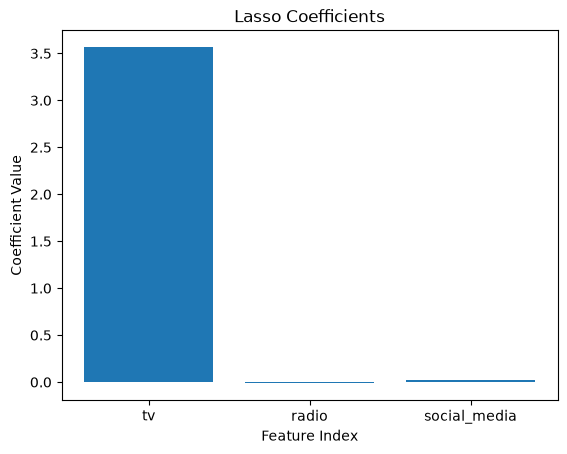

In [53]:
# Lasso is another regularization technique that adds a penalty term to the linear regression cost function,
# but it can also perform feature selection by shrinking some coefficients to zero, effectively removing them from the model.
# This can be useful when dealing with high-dimensional datasets where many features may be irrelevant or redundant.

from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.3)

lasso.fit(X_train, y_train)

lasso_coefficients = lasso.coef_
print("Lasso Coefficients: {}".format(lasso_coefficients))

sales_columns = sales_df.drop(["sales", "influencer"], axis=1).columns

plt.bar(sales_columns, lasso_coefficients)
plt.xlabel("Feature Index")
plt.ylabel("Coefficient Value")
plt.title("Lasso Coefficients")
plt.show()

In [54]:
lasso_score = lasso.score(X_test, y_test)
print("Lasso Regression Score: {}".format(lasso_score))

Lasso Regression Score: 0.9990254908428917


### Confusion Matrix

In [56]:
# Get data from a CSV file as a pandas DataFrame
diabetes_df = pd.read_csv("data/diabetes.csv")

# Inspect the DataFrame
diabetes_df.head()

,pregnancies,glucose,diastolic,triceps,insulin,bmi,dpf,age,diabetes
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [58]:
# Confusion matrix is a table used to evaluate the performance of a classification model by comparing the predicted labels with the actual labels.
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

X = diabetes_df[["bmi","age"]].values
y = diabetes_df["diabetes"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

print("Confusion Matrix:\n{}".format(confusion_matrix(y_test, y_pred)))
print("\nClassification Report:\n{}".format(classification_report(y_test, y_pred)))

Confusion Matrix:
[[77 22]
 [24 31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.78      0.77        99
           1       0.58      0.56      0.57        55

    accuracy                           0.70       154
   macro avg       0.67      0.67      0.67       154
weighted avg       0.70      0.70      0.70       154



      Precision is the ratio of true positive predictions to the total number of positive predictions made by the model.
      Recall is the ratio of true positive predictions to the total number of actual positive instances in the dataset.
      F1 score is a metric that combines precision and recall into a single value, providing a balanced measure of a model's performance.

### Logistic Regression

In [59]:
# Prepare data for logistic regression
X = diabetes_df.drop("diabetes", axis=1).values
y = diabetes_df["diabetes"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [68]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000) # Increase max_iter to ensure convergence

logreg.fit(X_train, y_train)

y_pred_probs = logreg.predict_proba(X_test)[:,1] # [:,1] gives the probabilities of the positive class (diabetes=1)

print("Predicted Probabilities: {}".format(y_pred_probs[:10]))

Predicted Probabilities: [0.43143208 0.32398361 0.15357715 0.04275406 0.20031545 0.26561286
 0.36863177 0.10225053 0.14508152 0.18734846]


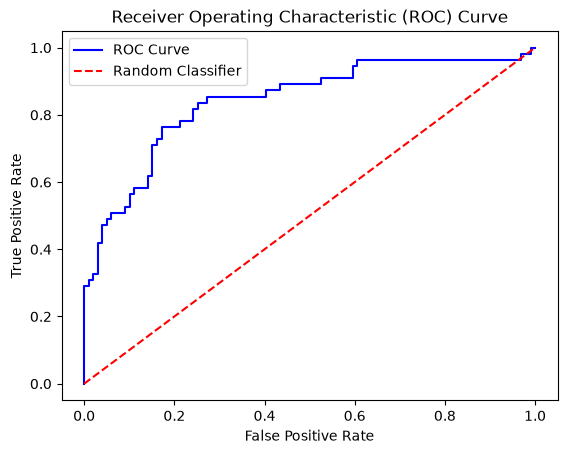

In [69]:
# ROC curve is a graphical representation of the performance
from sklearn.metrics import roc_curve

# Generate the false positive rate (fpr), true positive rate (tpr), and thresholds for the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_probs)

plt.plot(fpr, tpr, color='blue', label='ROC Curve')
plt.plot([0, 1], [0, 1], color='red', linestyle='--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [70]:
# ROC AUC (Area Under the Curve) is a metric that quantifies the overall performance of a binary classification model
# by calculating the area under the ROC curve.

from sklearn.metrics import roc_auc_score

print("ROC AUC Score: {}".format(roc_auc_score(y_test, y_pred_probs)))

# Confusion matrix
y_pred = logreg.predict(X_test)
print("Confusion Matrix:\n{}".format(confusion_matrix(y_test, y_pred)))

# Classification report
print("\nClassification Report:\n{}".format(classification_report(y_test, y_pred)))

ROC AUC Score: 0.8416896235078053
Confusion Matrix:
[[89 10]
 [24 31]]

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.90      0.84        99
           1       0.76      0.56      0.65        55

    accuracy                           0.78       154
   macro avg       0.77      0.73      0.74       154
weighted avg       0.78      0.78      0.77       154



### Hyperparameter Tuning

In [72]:
# GridSearchCV is a technique used to perform hyperparameter tuning for machine learning models.

from sklearn.model_selection import GridSearchCV

param_grid = {'alpha': np.linspace(0.00001, 1, 100)}

# instantiate lasso model
lasso_cv = GridSearchCV(Lasso(), param_grid, cv=5)

lasso_cv.fit(X_train, y_train)
print("Tuned lasso parameters: {}".format(lasso_cv.best_params_))
print("Tuned lasso best score: {}".format(lasso_cv.best_score_))

Tuned lasso parameters: {'alpha': np.float64(0.02021181818181818)}
Tuned lasso best score: 0.2641729450293141


In [76]:
# RandomizedSearchCV is another technique used for hyperparameter tuning, 
# but instead of exhaustively searching through all possible combinations of hyperparameters like GridSearchCV,
# it randomly samples a specified number of hyperparameter combinations from a given distribution.

from sklearn.model_selection import RandomizedSearchCV

params = {
        "tol": np.linspace(0.0001, 1.0, 50),
        "C": np.linspace(0.1, 1.0, 50),
        "class_weight": ["balanced", {0:0.8, 1:0.2}]}

logreg_random = RandomizedSearchCV(LogisticRegression( max_iter=1000), params, n_iter=10, cv=5, random_state=1)

logreg_random.fit(X_train, y_train)

print("Tuned Logistic Regression Parameters: {}".format(logreg_random.best_params_))
print("Tuned Logistic Regression Best Score: {}".format(logreg_random.best_score_))

Tuned Logistic Regression Parameters: {'tol': np.float64(0.04091224489795919), 'class_weight': 'balanced', 'C': np.float64(0.3204081632653062)}
Tuned Logistic Regression Best Score: 0.6564041050246568


### Preprocessing Data

In [102]:
# Get data from a CSV file as a pandas DataFrame
music_df = pd.read_csv("data/music.csv")

# Inspect the DataFrame
print(music_df.head())

print(music_df.shape)

   popularity  acousticness  danceability  ...       tempo  valence  genre
0        64.0       0.69400         0.610  ...  137.838000    0.352    NaN
1        31.0       0.73900         0.565  ...   75.537000    0.229  Anime
2        57.0       0.00879         0.433  ...  125.358000    0.461   Rock
3        63.0       0.01050         0.359  ...   89.259000    0.167   Rock
4         NaN       0.30100         0.511  ...  120.406497    0.496  Anime

[5 rows x 12 columns]
(1000, 12)


In [103]:
# Check how many unique genres are present in the dataset
print(music_df['genre'].nunique())

10


In [104]:
# Dummy variables are binary (0 or 1) variables created to represent categorical data in a numerical format,
# which allows machine learning algorithms to process categorical features effectively.

music_df_with_dummies = pd.get_dummies(music_df, drop_first=True) # Drop the first category to avoid multicollinearity

print(music_df_with_dummies.head())
print(music_df_with_dummies.shape)

   popularity  acousticness  danceability  ...  genre_Jazz  genre_Rap  genre_Rock
0        64.0       0.69400         0.610  ...       False      False       False
1        31.0       0.73900         0.565  ...       False      False       False
2        57.0       0.00879         0.433  ...       False      False        True
3        63.0       0.01050         0.359  ...       False      False        True
4         NaN       0.30100         0.511  ...       False      False       False

[5 rows x 20 columns]
(1000, 20)


In [106]:
# Regression with dummy variables is a technique used to include categorical features
# in regression models by converting them into dummy variables.

# Drop null values from the DataFrame for this example
music_df_with_dummies = music_df_with_dummies.dropna()

X = music_df_with_dummies.drop("popularity", axis=1).values
y = music_df_with_dummies["popularity"].values

ridge = Ridge(alpha=0.2)

# neg_mean_squared_error is used as the scoring metric for regression tasks 
scores = cross_val_score(ridge, X, y, cv=5, scoring='neg_mean_squared_error')

rmse = np.sqrt(-scores)
print("Cross-Validation RMSE Scores: {}".format(rmse))
print("Standard Deviation of target values: {}".format(np.std(y)))

# CV RMSE score is less than the standard deviation of the target values, 
# which indicates that the model is able to explain some of the variance in the target variable.

Cross-Validation RMSE Scores: [9.39963954 7.83157422 8.94741562 8.38517819 8.31510503]
Standard Deviation of target values: 14.40001272468775


### Handling Missing Data

In [241]:
# Get data from a CSV file as a pandas DataFrame
music_df = pd.read_csv("data/music.csv")

print(music_df.isna().sum().sort_values())

genre                 8
popularity           31
loudness             44
liveness             46
tempo                46
speechiness          59
instrumentalness     91
duration_ms          91
danceability        143
valence             143
energy              200
acousticness        200
dtype: int64


In [242]:
# Drop missing values accounting for less than 5% of the dataset, 
# and convert the "genre" column into a binary feature.

music_df = music_df.dropna(subset=["genre", "popularity", "loudness", "liveness", "tempo"])

music_df["genre"] = np.where(music_df["genre"] == "Rock", 1, 0) # Convert "Rock" genre to 1 and others to 0

print(music_df.isna().sum().sort_values())
print("Shape of the DataFrame after dropping missing values: {}".format(music_df.shape))

popularity            0
loudness              0
liveness              0
tempo                 0
genre                 0
duration_ms          29
instrumentalness     29
speechiness          53
danceability        127
valence             127
energy              178
acousticness        178
dtype: int64
Shape of the DataFrame after dropping missing values: (892, 12)


In [243]:
# Split the data into training and testing sets
X = music_df.drop("genre", axis=1).values
y = music_df["genre"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [245]:
# Pipeline for imputation using mean and build a KNN model to predict the genre of a song based on its features.

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

knn = KNeighborsClassifier(n_neighbors=3)

steps = [('imputer', imputer), ('knn', knn)]

pipeline = Pipeline(steps)

pipeline.fit(X_train, y_train)

y_pred = pipeline.predict(X_test)

print("Confusion Matrix:\n{}".format(confusion_matrix(y_test, y_pred)))
print("\nClassification Report:\n{}".format(classification_report(y_test, y_pred)))

Confusion Matrix:
[[50 34]
 [45 50]]

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.60      0.56        84
           1       0.60      0.53      0.56        95

    accuracy                           0.56       179
   macro avg       0.56      0.56      0.56       179
weighted avg       0.56      0.56      0.56       179



### Centering and Scaling

In [251]:
music_clean_df = pd.read_csv("data/music_clean.csv")

# Split the data into training and testing sets
X = music_clean_df.drop("loudness", axis=1).values
y = music_clean_df["loudness"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [252]:
# StandardScaler is a preprocessing technique used to standardize the features of a dataset
# by scaling them to have a mean of 0 and a standard deviation of 1.

from sklearn.preprocessing import StandardScaler

steps = [ ('scaler', StandardScaler()), ('lasso', Lasso(alpha=0.5))]

pipeline = Pipeline(steps)
pipeline.fit(X_train, y_train)

print("Pipeline Score: {}".format(pipeline.score(X_test, y_test)))

Pipeline Score: 0.7186202618702942


In [262]:
music_clean_df = pd.read_csv("data/music_clean.csv")
# Split the data into training and testing sets
X = music_clean_df.drop("genre", axis=1).values
y = music_clean_df["genre"].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

In [263]:
# Scaling for classification
steps = [('scaler', StandardScaler()), ('logreg', LogisticRegression(max_iter=1000))]
pipeline = Pipeline(steps)

parameters = {"logreg__C": np.linspace(0.001, 1.0, 20)}
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

cv = GridSearchCV(pipeline, param_grid = parameters)

cv.fit(X_train, y_train)
print("Best Parameters: {}".format(cv.best_params_))
print("Best Score: {}".format(cv.best_score_))

Best Parameters: {'logreg__C': np.float64(0.36905263157894735)}
Best Score: 0.9225


### Evaluating Multiple Models

In [267]:
music_df = pd.read_csv("data/music.csv")
music_df_with_dummies = pd.get_dummies(music_df, drop_first=True) # Drop the first category to avoid multicollinearity

# Drop all null values from the DataFrame for this example
music_df_with_dummies = music_df_with_dummies.dropna()

X = music_df_with_dummies.drop("energy", axis=1).values
y = music_df_with_dummies["energy"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

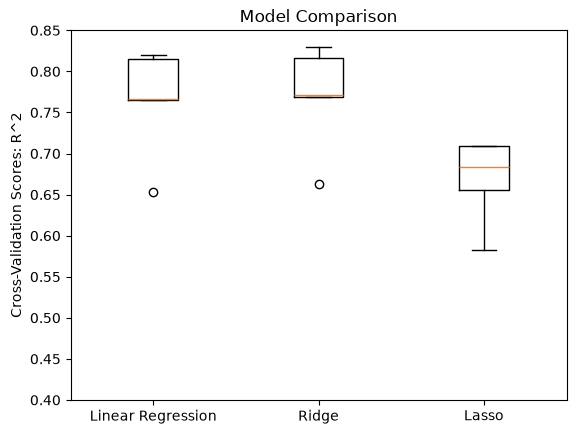

In [282]:
models = {"Linear Regression": LinearRegression(), "Ridge": Ridge(alpha=0.1), "Lasso": Lasso(alpha=0.1)}
results = []

for model in models.values():
    kf = KFold(n_splits=5, shuffle=True, random_state=1)
    
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf) # default scoring for regression is R^2
    
    results.append(cv_scores)
    
plt.boxplot(results, label=models.keys())
# Y boundaries for the boxplot difference of 0.05 btw each tick
plt.yticks([0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85])
plt.xticks([1, 2, 3], models.keys())
plt.title("Model Comparison")
plt.ylabel("Cross-Validation Scores: R^2")
plt.show()

In [284]:
# Predicting on test set

# Scale the features using StandardScaler and fit the models on the training set,
# then predict on the test set and calculate RMSE for each model.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.metrics import root_mean_squared_error

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    rmse = root_mean_squared_error(y_test, y_pred)
    print("{} RMSE: {}".format(name, rmse))

Linear Regression RMSE: 0.10763616790947259
Ridge RMSE: 0.107639408561012
Lasso RMSE: 0.16193901057732935


In [288]:
# For classification
music_df = pd.read_csv("data/music.csv")
music_df_with_dummies = pd.get_dummies(music_df, drop_first=True) # Drop the first category to avoid multicollinearity

# Drop all null values from the DataFrame for this example
music_df_with_dummies = music_df_with_dummies.dropna()

# convert popularity to a binary feature based on a threshold of mean
popularity_threshold = music_df_with_dummies["popularity"].mean()
music_df_with_dummies["popularity_binary"] = (music_df_with_dummies["popularity"] > popularity_threshold).astype(int)

music_df_with_dummies.drop("popularity", axis=1, inplace=True)

# change the name
music_df_with_dummies.rename(columns={"popularity_binary": "popularity"}, inplace=True)

X = music_df_with_dummies.drop("popularity", axis=1).values
y = music_df_with_dummies["popularity"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

/home/omer-yaslitas/projects/datacamp-ml-track/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


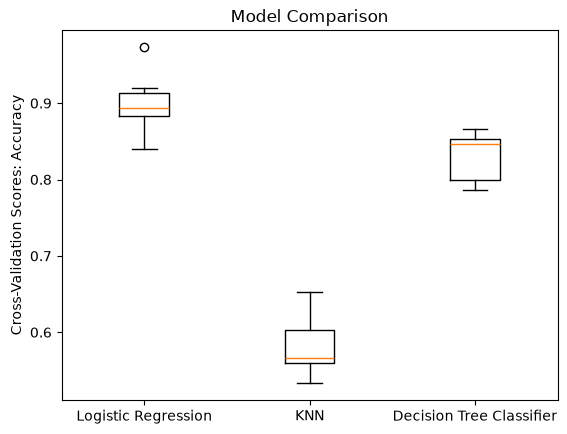

In [290]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {"Logistic Regression": LogisticRegression(max_iter=1000), 
        "KNN": KNeighborsClassifier(), "Decision Tree Classifier": DecisionTreeClassifier()}
results = []

for model in models.values():
    kf = KFold(n_splits=6, shuffle=True, random_state=1)
    
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf) # default scoring for classification is accuracy
    
    results.append(cv_scores)
    
plt.boxplot(results, label=models.keys())
plt.xticks([1, 2, 3], models.keys())
plt.title("Model Comparison")
plt.ylabel("Cross-Validation Scores: Accuracy")
plt.show()

In [291]:
# Create steps
steps = [("imp_mean", SimpleImputer()), 
         ("scaler", StandardScaler()), 
         ("logreg", LogisticRegression())]

# Set up pipeline
pipeline = Pipeline(steps)
params = {"logreg__solver": ["newton-cg", "saga", "lbfgs"],
         "logreg__C": np.linspace(0.001, 1.0, 10)}

# Create the GridSearchCV object
tuning = GridSearchCV(pipeline, param_grid=params)
tuning.fit(X_train, y_train)
y_pred = tuning.predict(X_test)

# Compute and print performance
print("Tuned Logistic Regression Parameters: {}, Accuracy: {}".format(tuning.best_params_, tuning.score(X_test, y_test)))

Tuned Logistic Regression Parameters: {'logreg__C': np.float64(0.223), 'logreg__solver': 'newton-cg'}, Accuracy: 0.9026548672566371
